In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [7]:
example_image = '/Volumes/My Book/alaska/native_res/BC_final/BC11TLSB/BC11TLSB_WSCT1734.JPG'

# BC11TLSB_WSCT1734.JPG	
top_point = (2846, 766)
bottom_point = (2831, 2365)


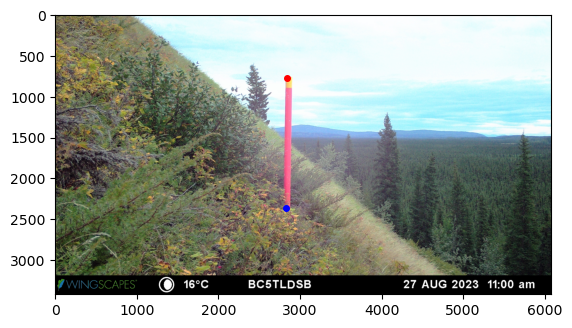

In [16]:
image = cv2.imread(example_image)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

plt.imshow(image_rgb)
plt.plot(top_point[0], top_point[1], 'ro', markersize=4, label='Top Point')     # Red circle
plt.plot(bottom_point[0], bottom_point[1], 'bo', markersize=4, label='Bottom Point')  # Blue circle


In [13]:


# Given distorted points
distorted_points = np.array([
    [[top_point[0], top_point[1]]],  # First point
    [[bottom_point[0], bottom_point[1]]]   # Second point
], dtype=np.float32)

# Camera parameters (from your previous code)
camera_matrix = np.array([
    [9406.3572, 0, 3163.8267],
    [0, 9262.9601, 1750.1192],
    [0, 0, 1]
], dtype=np.float32)

distortion_coeffs = np.array([
    0.4498,    # k1
    -1.9261,   # k2
    0,         # p1
    0,         # p2
    0          # k3
], dtype=np.float32)

# Undistort the points
undistorted_normalized = cv2.undistortPoints(distorted_points, camera_matrix, distortion_coeffs)

# The undistortPoints returns normalized points, to get pixel coordinates:
undistorted_points = []
for point in undistorted_normalized:
    x = point[0][0] * camera_matrix[0, 0] + camera_matrix[0, 2]  # x = x' * fx + cx
    y = point[0][1] * camera_matrix[1, 1] + camera_matrix[1, 2]  # y = y' * fy + cy
    undistorted_points.append((x, y))

# Now undistorted_points contains your two points in undistorted space
undistorted_x1, undistorted_y1 = undistorted_points[0]
undistorted_x2, undistorted_y2 = undistorted_points[1]

In [ ]:
## undistorted image 

image = cv2.imread(example_image)

matlab_intrinsic = np.array([
    [9406.3572, 0, 0],
    [0, 9262.9601, 0], 
    [3163.8267, 1750.1192, 1]
])

# Convert to OpenCV format
fx = matlab_intrinsic[0, 0]
fy = matlab_intrinsic[1, 1] 
cx = matlab_intrinsic[2, 0]
cy = matlab_intrinsic[2, 1]

camera_matrix = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
], dtype=np.float32)

# Radial distortion coefficients
# MATLAB: [k1, k2]
# OpenCV: [k1, k2, p1, p2, k3] where p1,p2 are tangential, k3 is 3rd radial
radial_distortion = [0.4498, -1.9261]
distortion_coeffs = np.array([
    radial_distortion[0],  # k1
    radial_distortion[1],  # k2
    0,                     # p1 (tangential)
    0,                     # p2 (tangential) 
    0                      # k3 (3rd order radial)
], dtype=np.float32)

image = cv2.undistort(image, camera_matrix, distortion_coeffs)


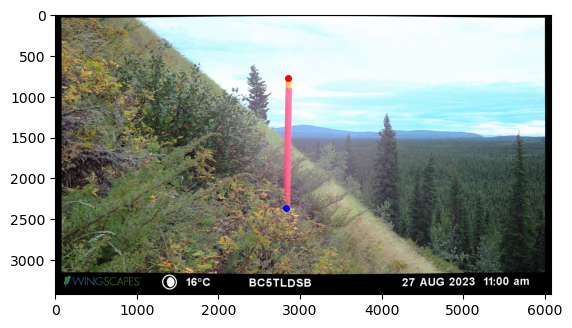

In [20]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
plt.imshow(image_rgb)
plt.plot(undistorted_x1, undistorted_y1, 'ro', markersize=4, label='Top Point')     # Red circle
plt.plot(undistorted_x2, undistorted_y2, 'bo', markersize=4, label='Bottom Point')  # Blue circle

In [27]:
def redistort_image(undistorted_image, camera_matrix, distortion_coeffs):
    h, w = undistorted_image.shape[:2]
    
    # Create coordinate grids for the undistorted image
    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    
    # Reshape to the format expected by cv2.projectPoints
    undistorted_points = np.stack([x_coords.ravel(), y_coords.ravel()], axis=1)
    
    # Convert to 3D points (add z=0)
    points_3d = np.zeros((undistorted_points.shape[0], 1, 3), dtype=np.float32)
    
    # Convert undistorted points to normalized coordinates first
    fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
    cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
    
    points_3d[:, 0, 0] = (undistorted_points[:, 0] - cx) / fx  # normalized x
    points_3d[:, 0, 1] = (undistorted_points[:, 1] - cy) / fy  # normalized y
    points_3d[:, 0, 2] = 0  # z = 0
    
    # Apply distortion using projectPoints
    distorted_points, _ = cv2.projectPoints(
        points_3d,
        np.zeros(3, dtype=np.float32),  # rotation vector (no rotation)
        np.zeros(3, dtype=np.float32),  # translation vector (no translation)
        camera_matrix,
        distortion_coeffs
    )
    
    # Reshape back to image coordinates
    map_x = distorted_points[:, 0, 0].reshape(h, w).astype(np.float32)
    map_y = distorted_points[:, 0, 1].reshape(h, w).astype(np.float32)
    
    # Remap the image
    redistorted_image = cv2.remap(undistorted_image, map_x, map_y, cv2.INTER_LINEAR)
    
    return redistorted_image

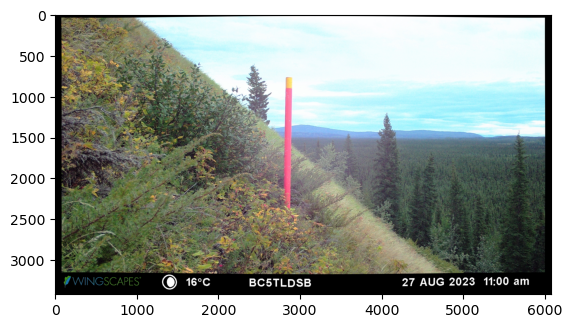

In [26]:
plt.imshow(image_rgb)

In [29]:
image_redistor = redistort_image(image_rgb, camera_matrix, distortion_coeffs)